# Explore and prepare intent-classification data

**Goal:** predict `intent` from the customer's `instruction`. The other source columns (`category`, `response`, and `flags`) are not used.

In [20]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split

## 1. Load the two columns needed by the model

In [21]:
env_file = Path.cwd() / ".env"
if not env_file.exists():
    env_file = Path.cwd().parent / ".env"
load_dotenv(env_file)

data_file = Path(os.environ["DATA_FILE"])
required_columns = {"instruction", "intent"}
source_columns = set(pd.read_csv(data_file, nrows=0).columns)
assert required_columns <= source_columns, f"Missing columns: {required_columns - source_columns}"

data = pd.read_csv(data_file, usecols=["instruction", "intent"])
print(f"Rows: {len(data):,}")
data.head()

Rows: 26,872


,instruction,intent
0,question about cancelling order {{Order Number}},cancel_order
1,i have a question about cancelling oorder {{Order Number}},cancel_order
2,i need help cancelling puchase {{Order Number}},cancel_order
3,I need to cancel purchase {{Order Number}},cancel_order
4,"I cannot afford this order, cancel purchase {{Order Number}}",cancel_order


## 2. Check quality and remove duplicates

In [22]:
quality = pd.DataFrame({
    "missing": data.isna().sum(),
    "blank": data.fillna("").apply(lambda column: column.str.strip().eq("").sum()),
    "unique": data.nunique(),
})
quality

,missing,blank,unique
instruction,0,0,24635
intent,0,0,27


In [23]:
assert data.notna().all().all(), "Missing instructions or intents found."

data["instruction"] = data["instruction"].str.strip()
data["intent"] = data["intent"].str.strip()
assert not data.eq("").any().any(), "Blank instructions or intents found."

conflicts = data.groupby("instruction")["intent"].nunique().gt(1).sum()
assert conflicts == 0, "Some identical instructions have different intents."

duplicates_removed = data.duplicated("instruction").sum()
data = data.drop_duplicates("instruction").reset_index(drop=True)

print(f"Duplicate instructions removed: {duplicates_removed:,}")
print(f"Clean rows remaining: {len(data):,}")

Duplicate instructions removed: 2,237
Clean rows remaining: 24,635


## 3. Fill template placeholders

Replace every dataset placeholder with a plausible synthetic value. A fixed seed makes the generated data identical on every run.

In [24]:
placeholder_pattern = r"\{\{.*?\}\}"
placeholder_rows = data["instruction"].str.contains(placeholder_pattern, regex=True)
examples = data.loc[placeholder_rows, ["instruction"]].head(5).rename(
    columns={"instruction": "original_instruction"}
)

rng = random.Random(42)

def fill_placeholders(text):
    values = {
        "Order Number": f"ORD-{rng.randint(100000, 999999)}",
        "Account Type": rng.choice(["personal account", "business account", "premium account"]),
        "Person Name": rng.choice(["Alex Morgan", "Sam Taylor", "Jamie Smith", "Jordan Lee"]),
        "Account Category": rng.choice(["personal", "business", "student", "premium"]),
        "Refund Amount": str(rng.randint(10, 500)),
        "Currency Symbol": rng.choice(["$", "€", "£"]),
        "Delivery City": rng.choice(["Cairo", "London", "Madrid", "Toronto"]),
        "Delivery Country": rng.choice(["Egypt", "Canada", "Spain", "United Kingdom"]),
        "Invoice Number": f"INV-{rng.randint(100000, 999999)}",
    }
    for name, value in values.items():
        text = text.replace("{{" + name + "}}", value)
    return text

data["instruction"] = data["instruction"].map(fill_placeholders)
remaining_placeholders = data["instruction"].str.contains(placeholder_pattern, regex=True).sum()
assert remaining_placeholders == 0, "Some placeholders were not replaced."

examples["filled_instruction"] = data.loc[examples.index, "instruction"]
filled_conflicts = data.groupby("instruction")["intent"].nunique().gt(1).sum()
assert filled_conflicts == 0, "Filled instructions have conflicting intents."
new_duplicates = data.duplicated("instruction").sum()
data = data.drop_duplicates("instruction").reset_index(drop=True)
assert data["instruction"].is_unique

print(f"Instructions filled: {placeholder_rows.sum():,}")
print(f"New duplicates removed after filling: {new_duplicates:,}")
examples

Instructions filled: 4,433
New duplicates removed after filling: 39


,original_instruction,filled_instruction
0,question about cancelling order {{Order Number}},question about cancelling order ORD-770487
1,i have a question about cancelling oorder {{Order Number}},i have a question about cancelling oorder ORD-876646
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase ORD-629903
3,I need to cancel purchase {{Order Number}},I need to cancel purchase ORD-717889
4,"I cannot afford this order, cancel purchase {{Order Number}}","I cannot afford this order, cancel purchase ORD-325772"


## 4. Explore intents and instruction lengths

In [25]:
intent_counts = data["intent"].value_counts().sort_values()
imbalance_ratio = intent_counts.max() / intent_counts.min()
print(f"Largest class / smallest class: {imbalance_ratio:.2f}x")
intent_counts.to_frame("rows")

Largest class / smallest class: 2.03x


,rows
intent,
cancel_order,493
delivery_options,660
track_refund,707
edit_account,757
track_order,807
switch_account,856
change_order,870
create_account,883
get_invoice,909


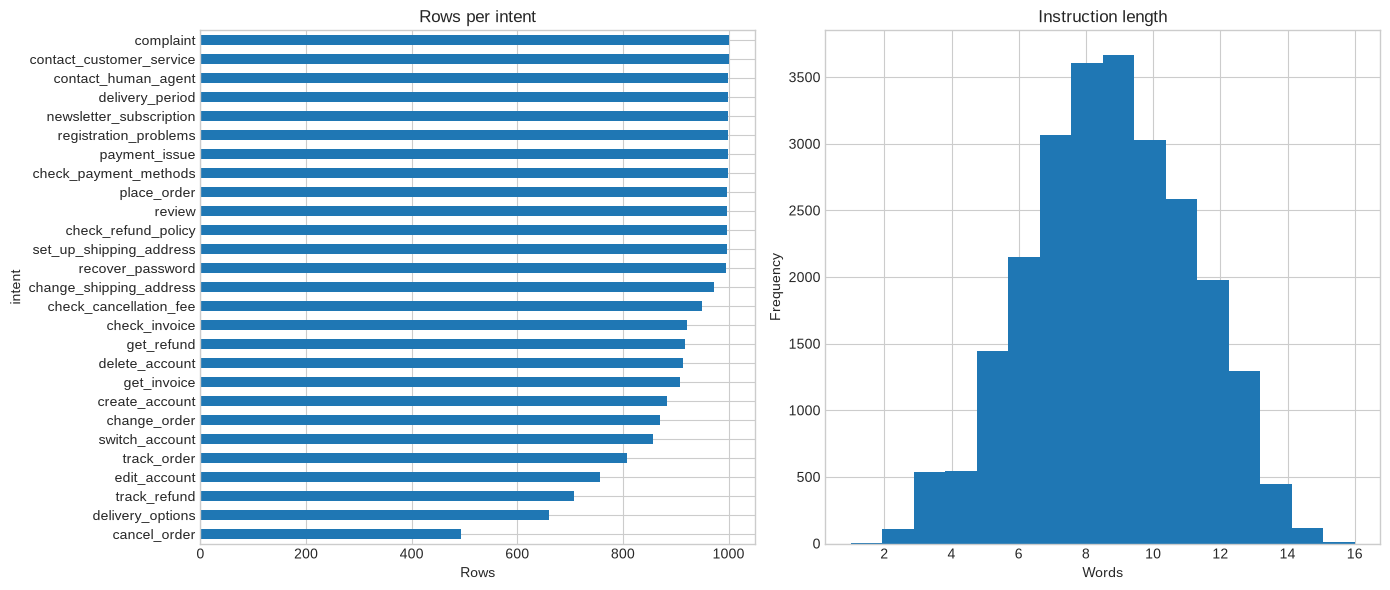

,words
count,24596.000000
mean,8.738535
std,2.575973
min,1.000000
5%,5.000000
50%,9.000000
95%,13.000000
max,16.000000


In [26]:
text_lengths = data["instruction"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
intent_counts.plot.barh(ax=axes[0], title="Rows per intent")
text_lengths.plot.hist(bins=16, ax=axes[1], title="Instruction length")
axes[0].set_xlabel("Rows")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

text_lengths.describe(percentiles=[0.05, 0.50, 0.95]).to_frame("words")

In [27]:
has_placeholder = data["instruction"].str.contains(placeholder_pattern, regex=True)
has_digit = data["instruction"].str.contains(r"\d", regex=True)
has_non_ascii = data["instruction"].map(lambda text: not text.isascii())

pd.Series({
    "unfilled template placeholders": has_placeholder.sum(),
    "rows with digits": has_digit.sum(),
    "rows with non-ASCII characters": has_non_ascii.sum(),
}, name="rows").to_frame()

,rows
unfilled template placeholders,0
rows with digits,3436
rows with non-ASCII characters,120


## 5. Split Data

In [28]:
train_data, test_data = train_test_split(
    data, test_size=0.20, random_state=42, stratify=data["intent"]
)
train_data, validation_data = train_test_split(
    train_data, test_size=0.125, random_state=42, stratify=train_data["intent"]
)

splits = {
    "train": train_data.reset_index(drop=True),
    "validation": validation_data.reset_index(drop=True),
    "test": test_data.reset_index(drop=True),
}

assert sum(len(frame) for frame in splits.values()) == len(data)
assert all(frame["intent"].nunique() == data["intent"].nunique() for frame in splits.values())
assert not (set(splits["train"]["instruction"]) & set(splits["validation"]["instruction"]))
assert not (set(splits["train"]["instruction"]) & set(splits["test"]["instruction"]))
assert not (set(splits["validation"]["instruction"]) & set(splits["test"]["instruction"]))

pd.DataFrame({
    "rows": {name: len(frame) for name, frame in splits.items()},
    "intents": {name: frame["intent"].nunique() for name, frame in splits.items()},
})

,rows,intents
train,17216,27
validation,2460,27
test,4920,27


In [29]:
output_dir = Path(os.environ["DATA_PATH"])
assert output_dir.is_dir(), f"Output directory does not exist: {output_dir}"

for name, frame in splits.items():
    path = output_dir / f"{name}_split.parquet"
    frame.to_parquet(path, index=False)
    saved = pd.read_parquet(path)
    assert list(saved.columns) == ["instruction", "intent"]
    assert len(saved) == len(frame)
    print(f"Saved {name}: {len(frame):,} rows -> {path.name}")

Saved train: 17,216 rows -> train_split.parquet
Saved validation: 2,460 rows -> validation_split.parquet
Saved test: 4,920 rows -> test_split.parquet
